Abon, Benedict Aldous A.<br>
CPE311 - CPE22S3<br>
03/08/26<br>
03/08/26<br>
Engr. Neil Barton James Matira<br>

# Hands-on Activity 9.2 Customized Visualizations using Seaborn

## Procedure and Analysis

### Introduction to Seaborn

About the Data<br>
In this notebook, we will be working with 2 datasets:<br>
- Facebook's stock price throughout 2018 (obtained using the stock_analysis package)
- Earthquake data from September 18, 2018 - October 13, 2018 (obtained from the US Geological Survey (USGS) using the USGS API)

In [232]:
# Setup
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

fb = pd.read_csv(
 '../HOA_9_1/fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('../HOA_9_1/earthquakes-1.csv')

Categorical Data

In [233]:
quakes.assign(
    time=lambda x: pd.to_datetime(x.time, unit='ms')
).set_index('time').loc['2018-09-28'].query(
    "parsed_place == 'Indonesia' and tsunami == 1 and mag == 7.5"
)

,mag,magType,place,tsunami,parsed_place
time,,,,,
2018-09-28 10:02:43.480,7.5,mww,"78km N of Palu, Indonesia",1,Indonesia


stripplot()<br>
The stripplot() function helps us visualize categorical data on one axis and numerical data on the other. We also now have the option of coloring our points using a column of our data (with the hue parameter). Using a strip plot, we can see points for each earthquake that was measured with a given magType and what its magnitude was; however, it isn't too easy to see density of the points due to overlap:

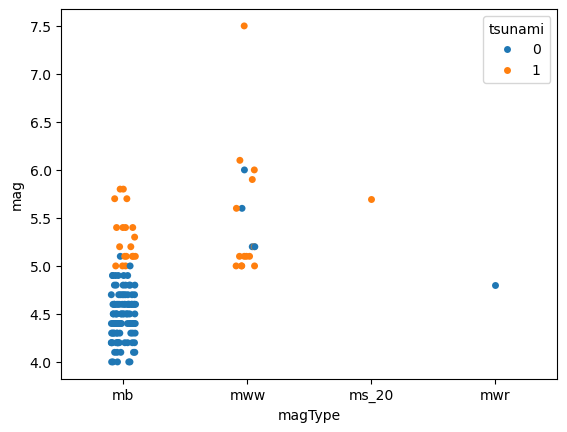

In [234]:
sns.stripplot(
    x='magType',
    y='mag',
    hue='tsunami',
    data=quakes.query('parsed_place == "Indonesia"')
)
plt.show()

swarmplot()<br>
The bee swarm plot helps address this issue be keeping the points from overlapping. Notice how many more points we can see for the blue section of the mb magType:

c:\Users\Aldous\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


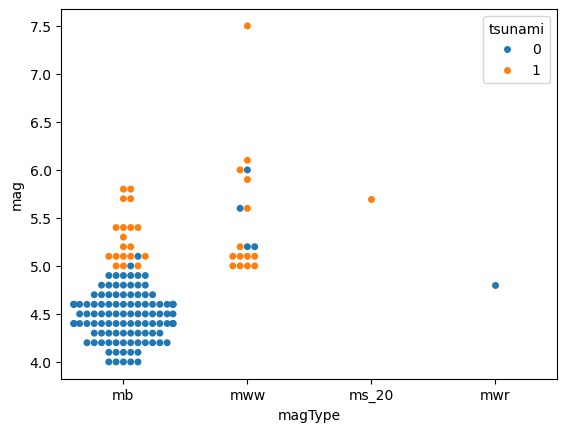

In [235]:
sns.swarmplot(
    x='magType',
    y='mag',
    hue='tsunami',
    data=quakes.query('parsed_place == "Indonesia"')
)
plt.show()

Correlations and Heatmaps

heatmap()<br>
An easier way to create correlation matrix is to use seaborn:

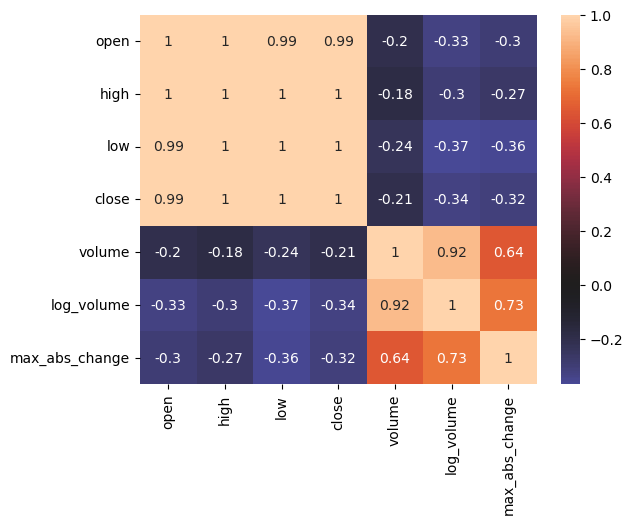

In [236]:
sns.heatmap(
    fb.sort_index().assign(
    log_volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).corr(), annot=True, center=0
)
plt.show()

pairplot()<br>
The pair plot is seaborn's answer to the scatter matrix we saw in the pandas subplotting notebook:

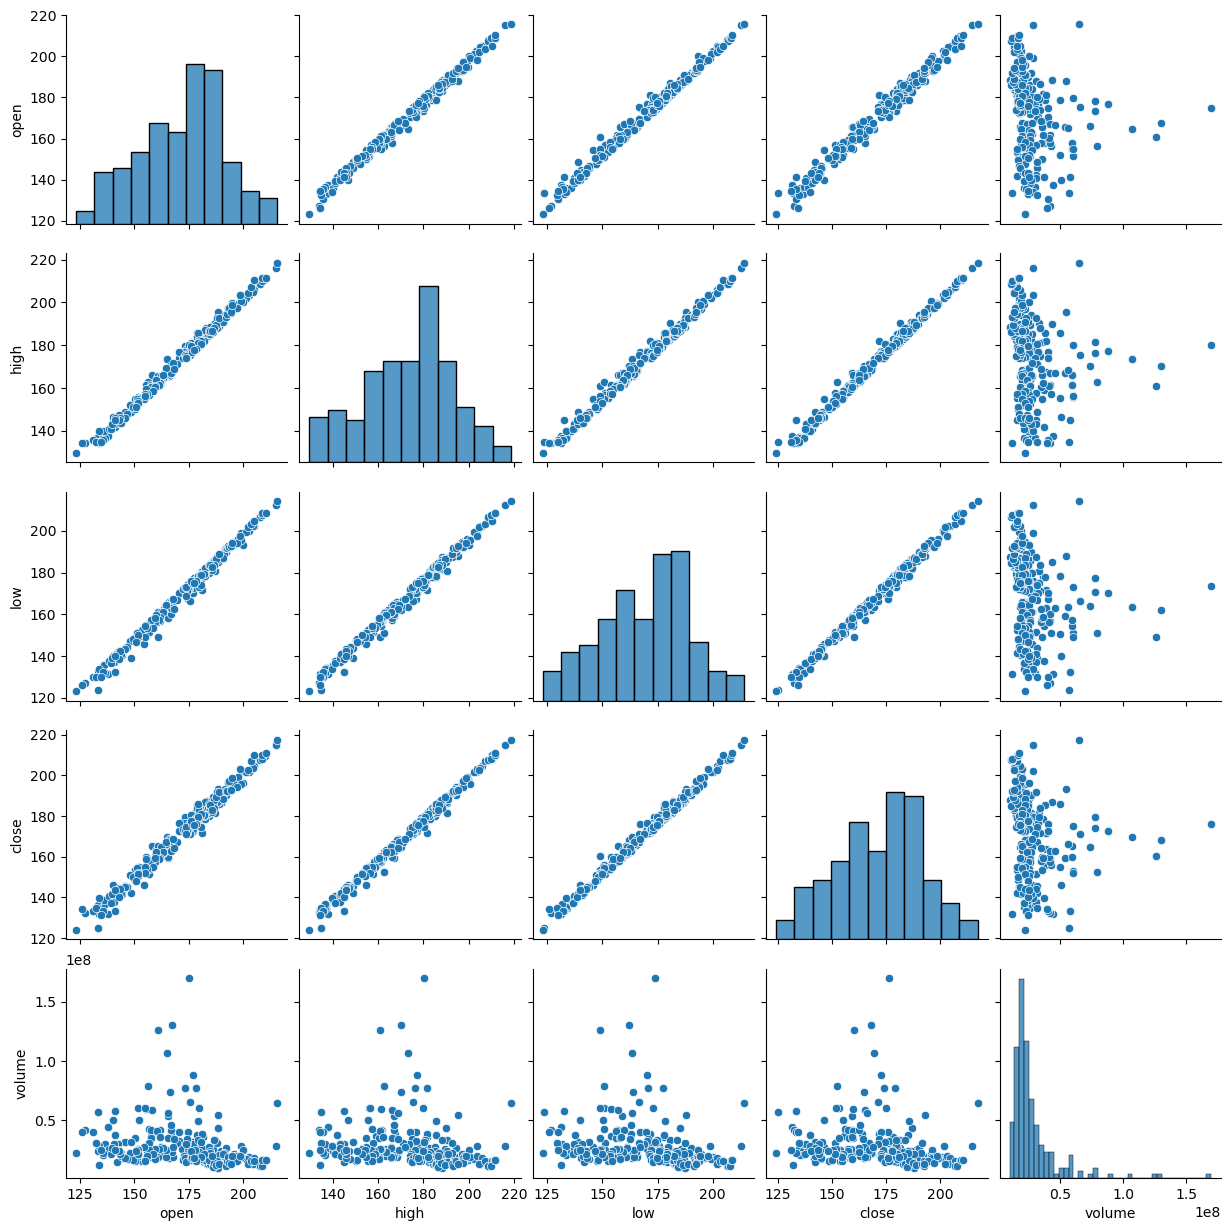

In [237]:
sns.pairplot(fb)
plt.show()

Just as with pandas we can specify what to show along the diagonal; however, seaborn also allows us to color the data based on another column (or other data with the
same shape):

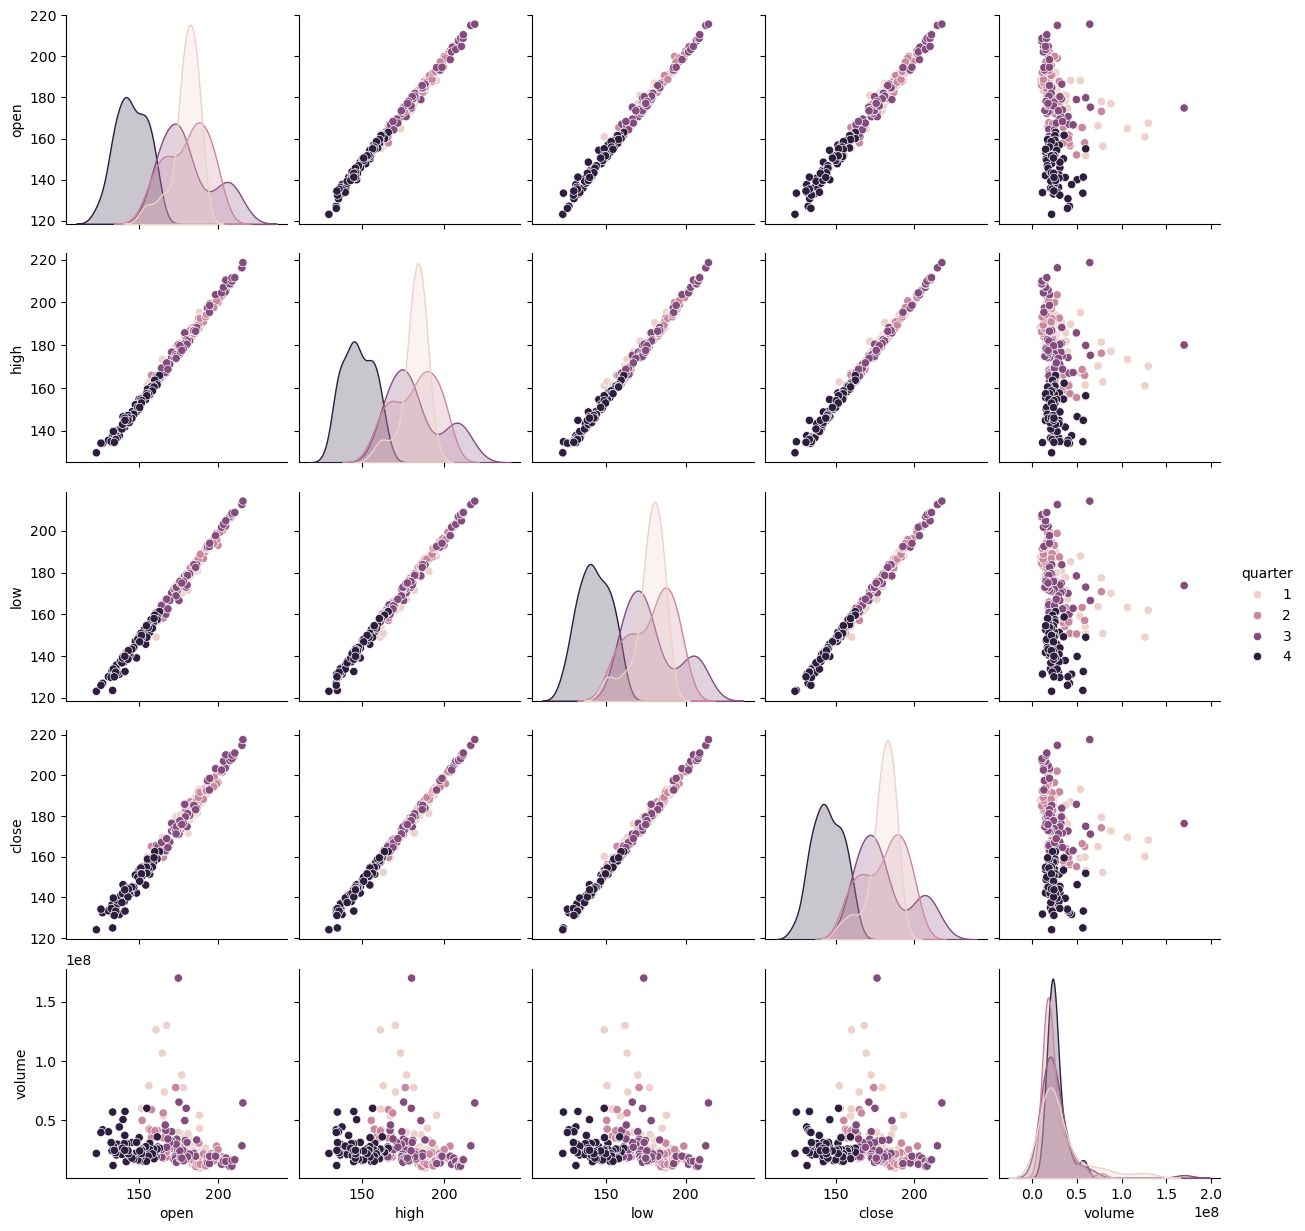

In [238]:
sns.pairplot(
    fb.assign(quarter=lambda x: x.index.quarter),
    diag_kind='kde',
    hue='quarter'
)
plt.show()

jointplot()<br>
The joint plot allows us to visualize the relationship between two variables, like a scatter plot. However, we get the added benefit of being able to visualize their distributions at the same time (as a histogram or KDE). The default options give us a scatter plot in the center and histograms on the sides:

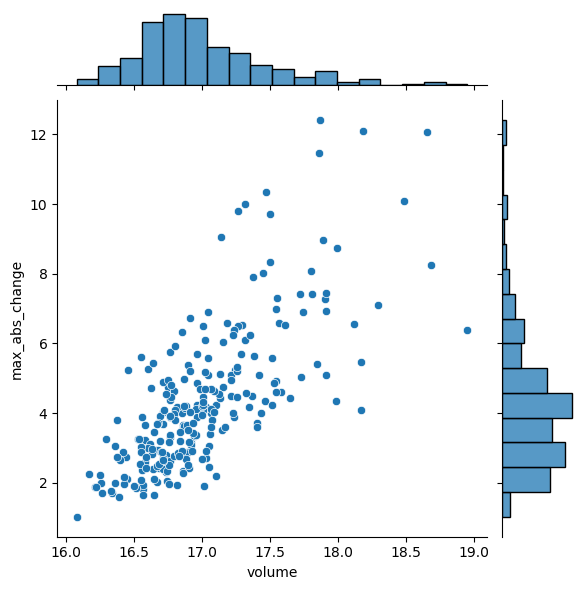

In [239]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)
plt.show()

By changing the kind argument, we can change how the center of the plot is displayed. For example, we can pass kind='hex' for hexbins:

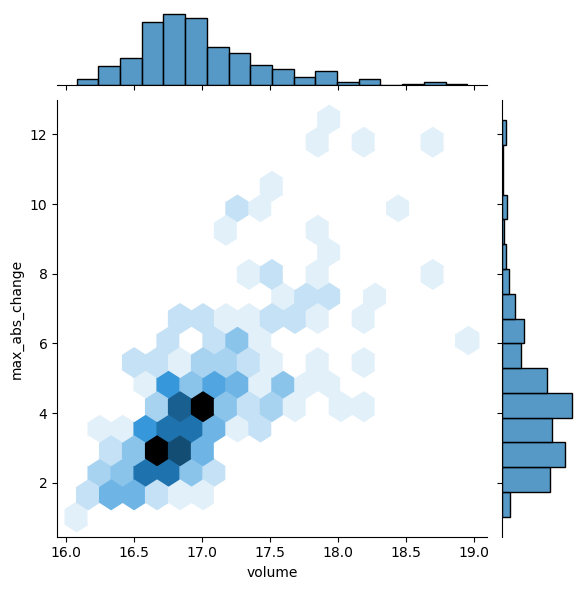

In [240]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='hex',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)
plt.show()

If we specify kind='reg' instead, we get a regression line in the center and KDEs on the sides:

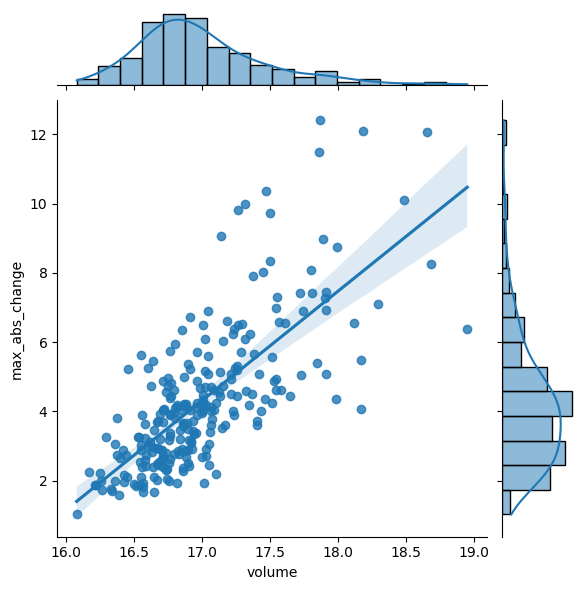

In [241]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='reg',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)
plt.show()

If we pass kind='resid' , we get the residuals from the aforementioned regression:

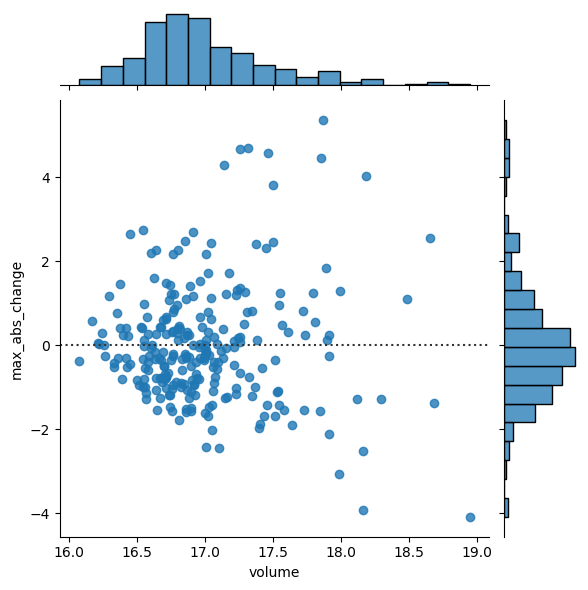

In [242]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='resid',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)
plt.show()

Finally, if we pass kind='kde' , we get a contour plot of the joint density estimate with KDEs along the sides:

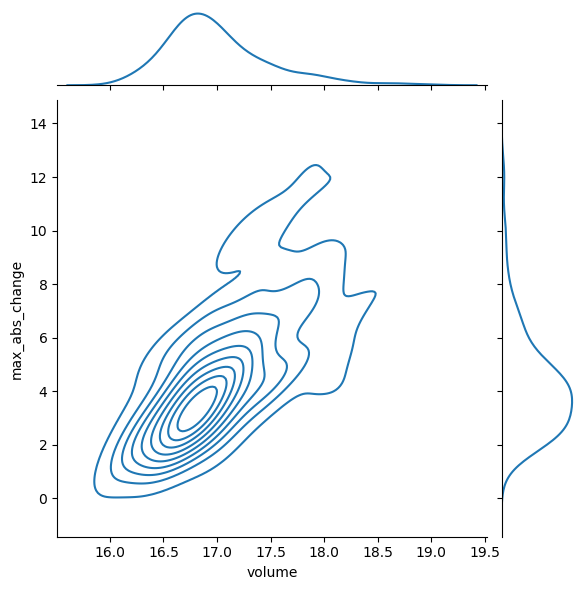

In [243]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='kde',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)
plt.show()

Regression Plots<br>
We are going to use seaborn to visualize a linear regression between the log of the volume traded in Facebook stock and the maximum absolute daily change (daily high
stock price - daily low stock price). To do so, we first need to isolate this data:

In [244]:
fb_reg_data = fb.assign(
    volume=np.log(fb.volume),
    max_abs_change=fb.high-fb.low
).iloc[:,-2:]

Since we want to visualize each column as the regressor, we need to look at permutations of their order. Permutations and combinations (among other things) are made easy in Python with itertools , so let's import it:

In [245]:
import itertools

itertools gives us efficient iterators. Iterators are objects that we loop over, exhausting them. This is an iterator from itertools ; notice how the second loop doesn't do anything

In [246]:
iterator = itertools.repeat("I'm an iterator", 1)

for i in iterator:
    print(f'--> {i}')
print('This printed once because the iterator has been exhausted')
for i in iterator:
    print(f'--> {i}')

--> I'm an iterator
This printed once because the iterator has been exhausted


Iterables are objects that can be iterated over. When entering a loop, an iterator is made from the iterable to handle the iteration. Iterators are iterables, but not all iterables
are iterators. A list is an iterable. If we turn that iterator into an iterable (a list in this case), the second loop runs:

In [247]:
iterable = list(itertools.repeat("I'm an iterable", 1))

for i in iterable:
   print(f'--> {i}')
print('This prints again because it\'s an iterable:')
for i in iterable:
    print(f'--> {i}')

--> I'm an iterable
This prints again because it's an iterable:
--> I'm an iterable


The reg_resid_plots() function from the reg_resid_plot.py module in this folder uses regplot() and residplot() from seaborn along with itertools to plot the regression and residuals side-by-side:

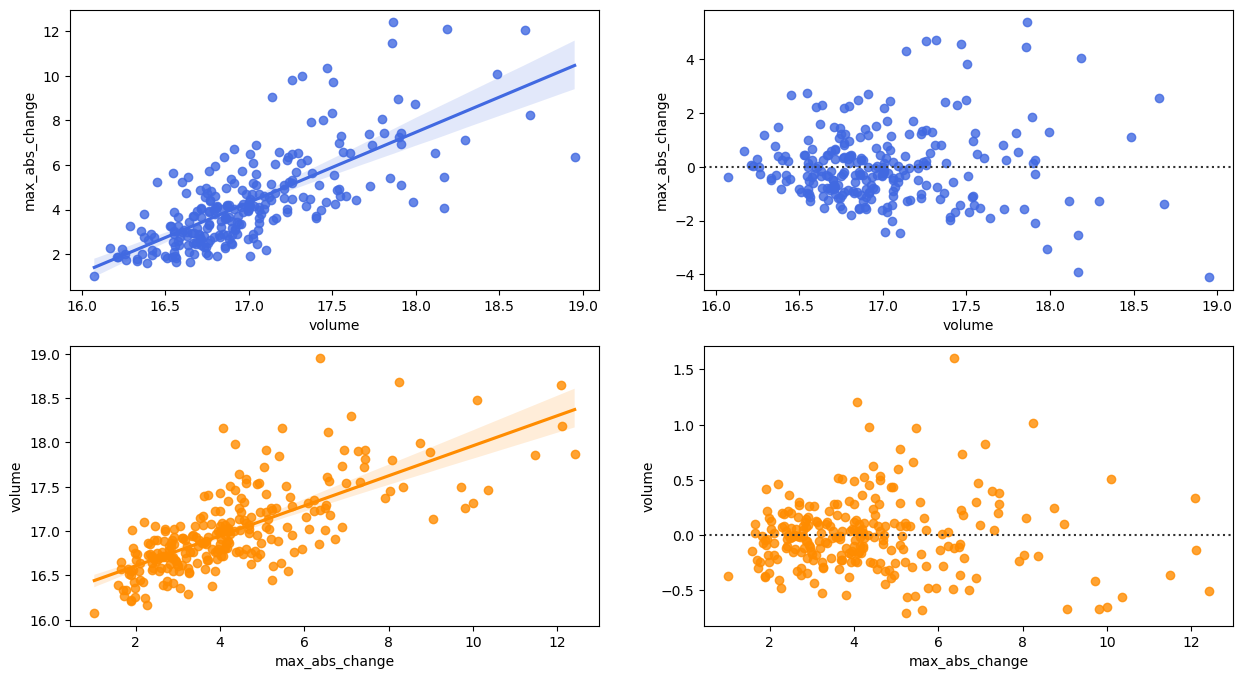

In [248]:
from reg_resid_plot import reg_resid_plots
reg_resid_plots(fb_reg_data)

We can use lmplot() to split our regression across subsets of our data. For example, we can perform a regression per quarter on the Facebook stock data:

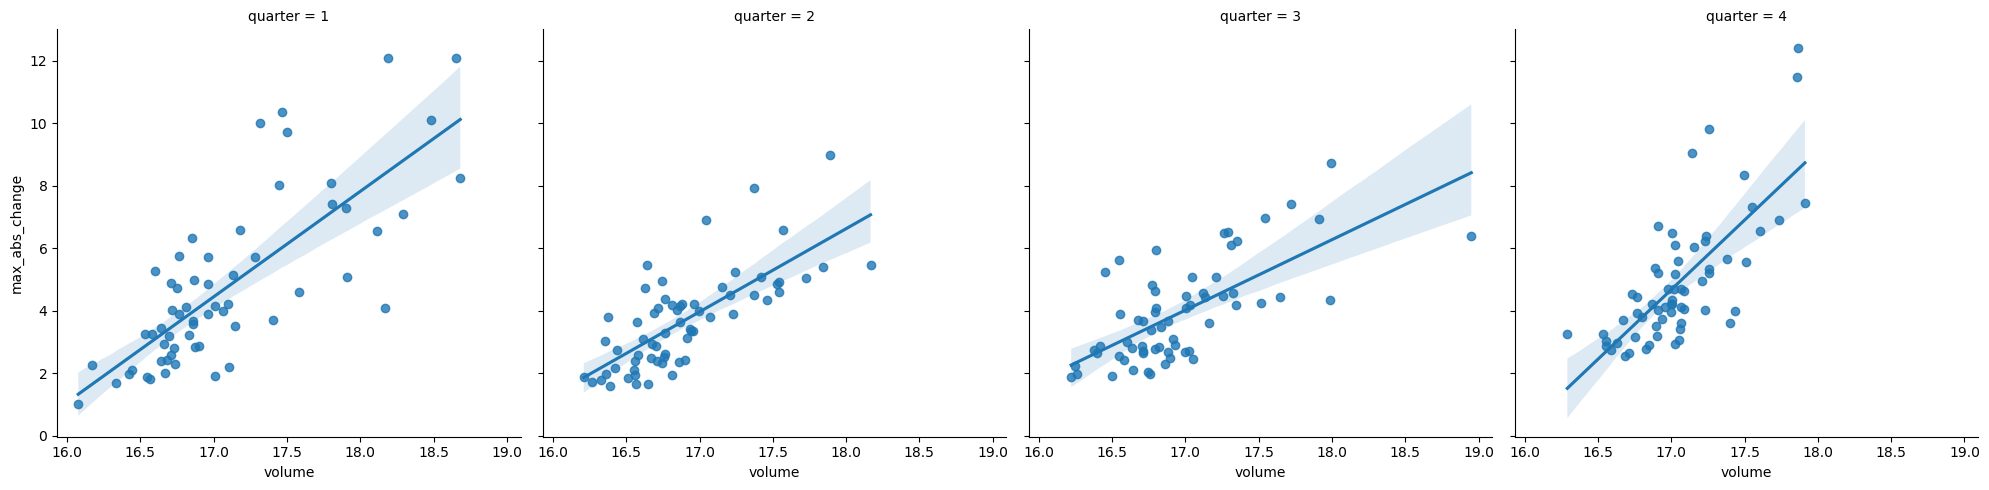

In [249]:
sns.lmplot(
    x='volume',
    y='max_abs_change',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high-fb.low,
        quarter=lambda x: x.index.quarter
    ),
    col='quarter'
)
plt.show()

Distributions<br>
Seaborn provides some new plot types for visualizing distributions in additional to its own versions of the plot types we discussed in chapter 5 (in this notebook).

boxenplot()<br>
The boxenplot is a box plot that shows additional quantiles:

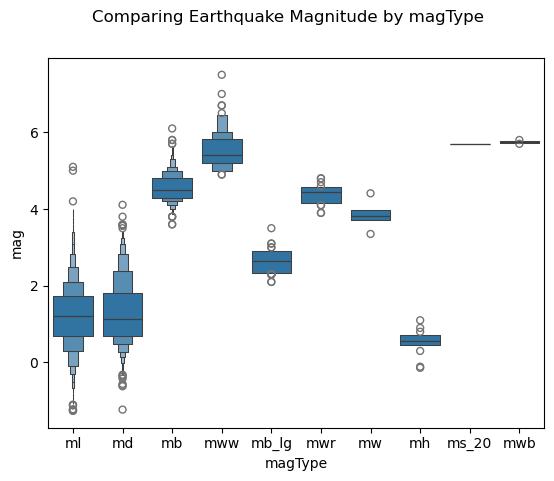

In [250]:
sns.boxenplot(
    x='magType',
    y='mag',
    data=quakes[['magType','mag']]
)
plt.suptitle('Comparing Earthquake Magnitude by magType')
plt.show()

violinplot()<br>
Box plots lose some information about the distribution, so we can use violin plots which combine box plots and KDEs

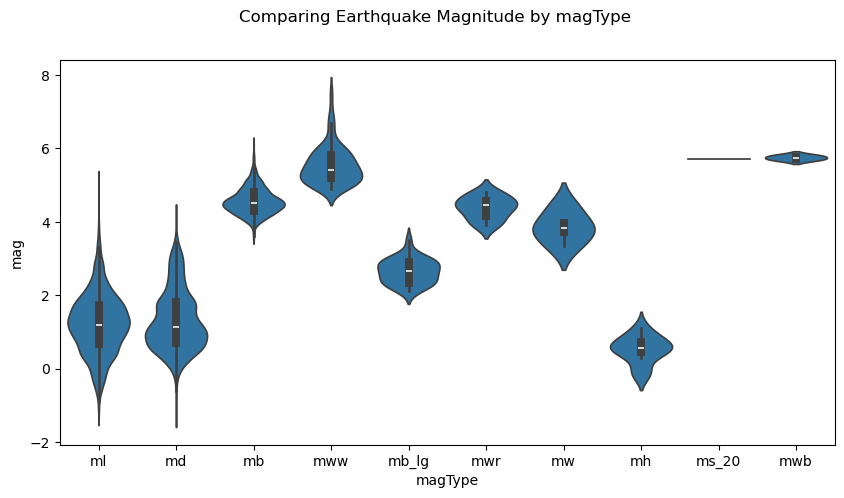

In [251]:
fig, axes = plt.subplots(figsize=(10,5))
sns.violinplot(
    x='magType',
    y='mag',
    data=quakes[['magType','mag']],
    ax=axes, density_norm='width' # all violins have same width
)
plt.suptitle('Comparing Earthquake Magnitude by magType')
plt.show()

# use density norm instead of scale

Faceting<br>
We can create subplots across subsets of our data by faceting. First, we create a FacetGrid specifying how to layout the plots (which categorical column goes along the
rows and which one along the columns). Then, we call the map() method of the FacetGrid and pass in the plotting function we want to use (along with any additional
arguments).<br><br>
Let's make histograms showing the distribution of earthquake magnitude in California, Alaska, and Hawaii faceted by magType and parse_placed :

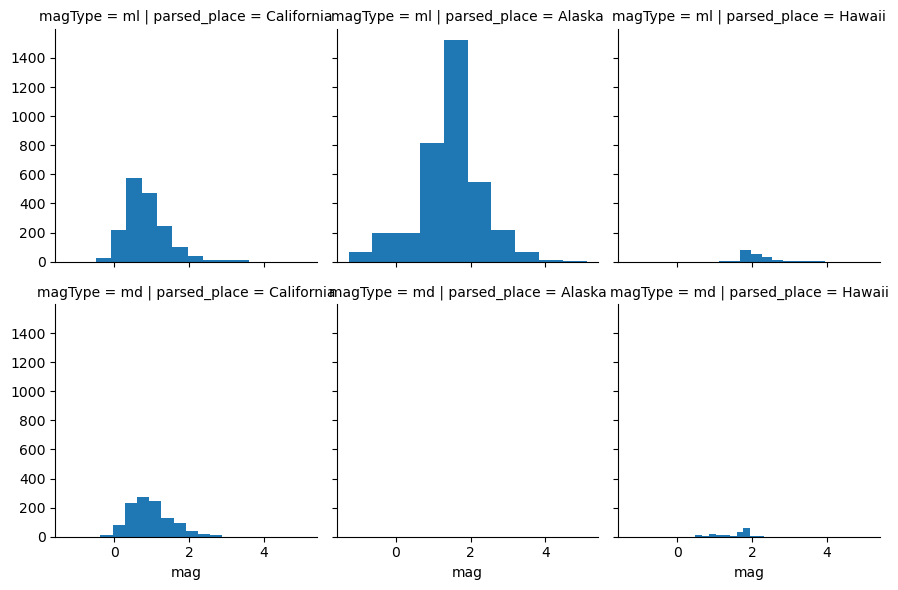

In [252]:
g = sns.FacetGrid(
    quakes[
        (quakes.parsed_place.isin([
            'California', 'Alaska', 'Hawaii'
        ]))\
            & (quakes.magType.isin(['ml', 'md']))
    ],
    row='magType',
    col='parsed_place'
)
g = g.map(plt.hist, 'mag')
plt.show()

### Formatting Plots

Titles and Axis Labels
- plt.suptitle() adds a title to plots and subplots
- plt.title() adds a title to a single plot. Note if you use subplots, it will only put the title on the last subplot, so you will need to use plt.suptitle()
- plt.xlabel() labels the x-axis
- plt.ylabel() labels the y-axis


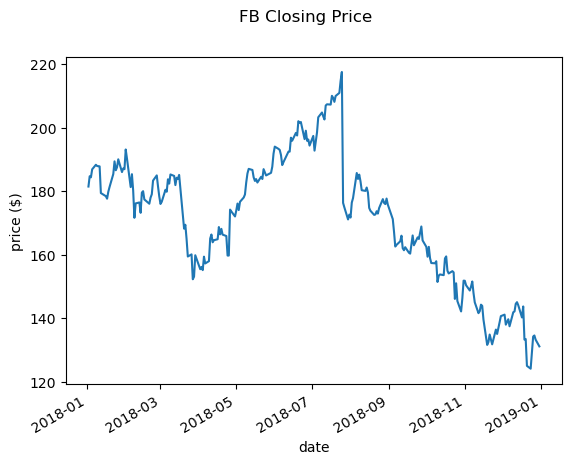

In [253]:
fb.close.plot()
plt.suptitle('FB Closing Price')
plt.xlabel('date')
plt.ylabel('price ($)')
plt.show()

plt.suptitle() vs. plt.title()<br>
Check out what happens when we call plt.title() with subplots:

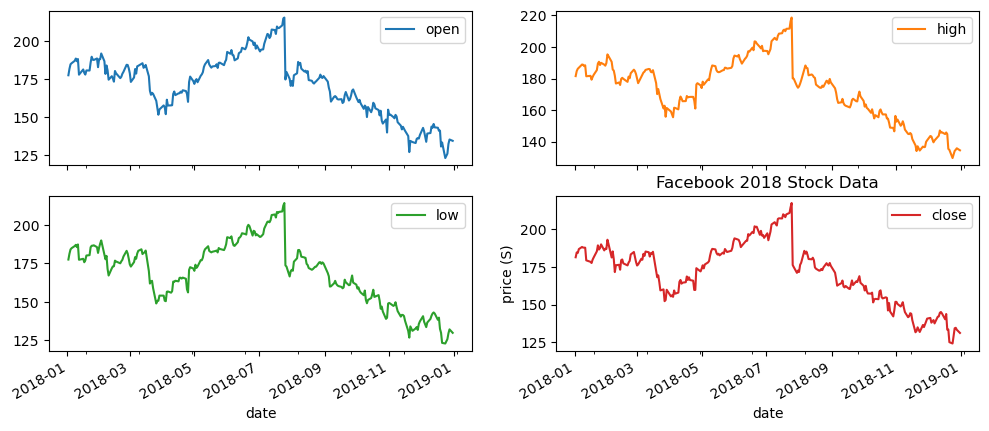

In [254]:
fb.iloc[:,:4].plot(subplots=True, layout=(2,2), figsize=(12,5))
plt.title('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price (S)')
plt.show()

Simply getting into the habit of using plt.suptitle() instead of plt.title() will save you this confusion:

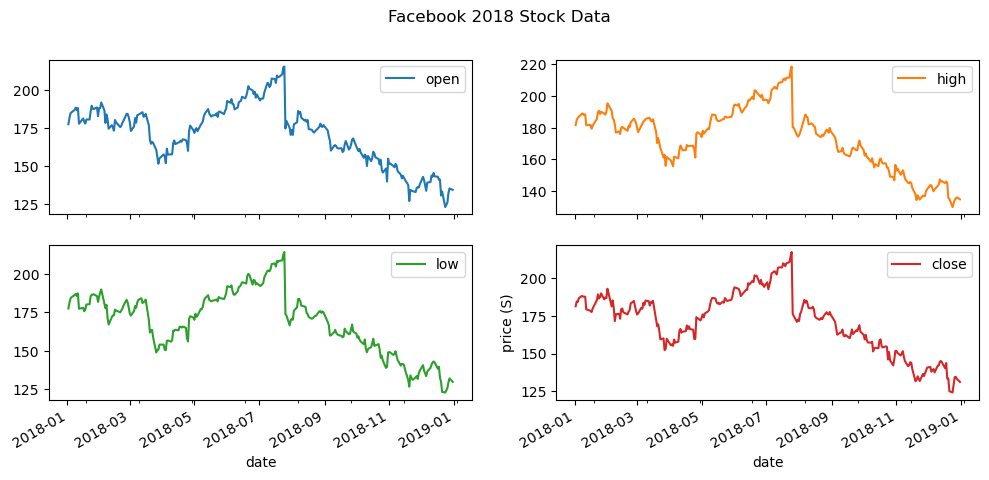

In [255]:
fb.iloc[:,:4].plot(subplots=True, layout=(2,2), figsize=(12,5))
plt.suptitle('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price (S)')
plt.show()

Legends<br>
plt.legend() adds a legend to the plot. We can specify where to place it with the loc parameter:

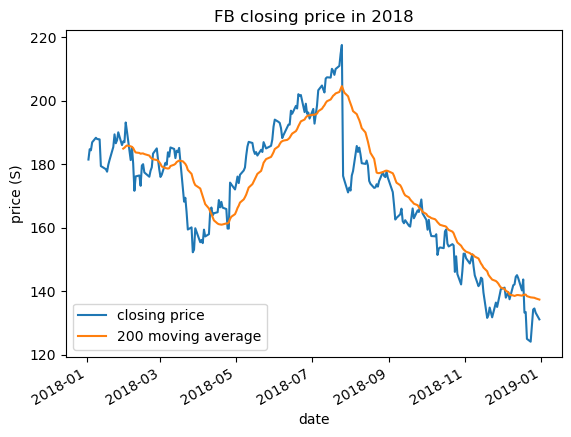

In [256]:
fb.assign(
    ma=lambda x: x.close.rolling(20).mean()
).plot(
    y=['close','ma'],
    title='FB closing price in 2018',
    label=['closing price', '200 moving average']
)
plt.legend(loc='lower left')
plt.ylabel('price (S)')
plt.show()

Formattting Axes<br>
Specifying axis limits<br>
plt.xlim() and plt.ylim() can be used to specify the minimum and maximum values for the axis. Passing None will have matplotlib determine the limit.

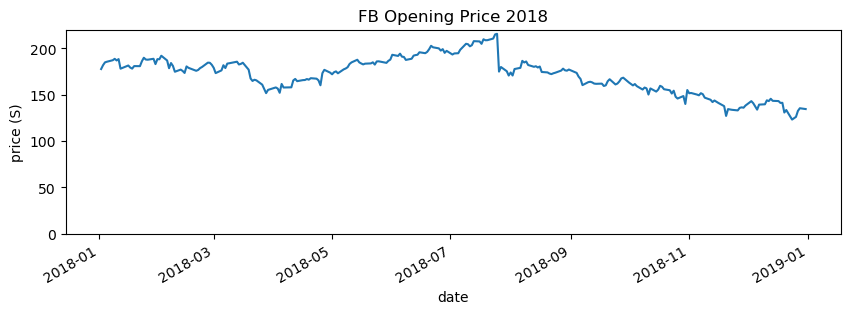

In [257]:
fb.open.plot(figsize=(10,3), title='FB Opening Price 2018')
plt.ylim(0, None)
plt.ylabel('price (S)')
plt.show()

Formatting the Axis Ticks<br>
We can use plt.xticks() and plt.yticks() to provide tick labels and specify, which ticks to show. Here, we show every other month:

In [258]:
import calendar

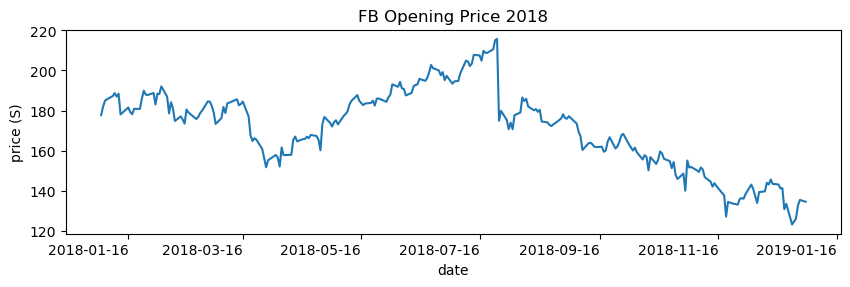

In [259]:
fb.open.plot(figsize=(10,3), rot=0, title='FB Opening Price 2018')
locs, labels = plt.xticks()
plt.xticks(ticks=locs + 15, label=calendar.month_name[1:])
plt.ylabel('price (S)')
plt.show()

Using ticker<br>
PercentFormatter<br>
We can use ticker.PercentFormatter and specify the denominator ( xmax ) to use when calculating the percentages. This gets passed to the set_major_formatter() method of the xaxis or yaxis on the Axes.

In [260]:
import matplotlib.ticker as ticker

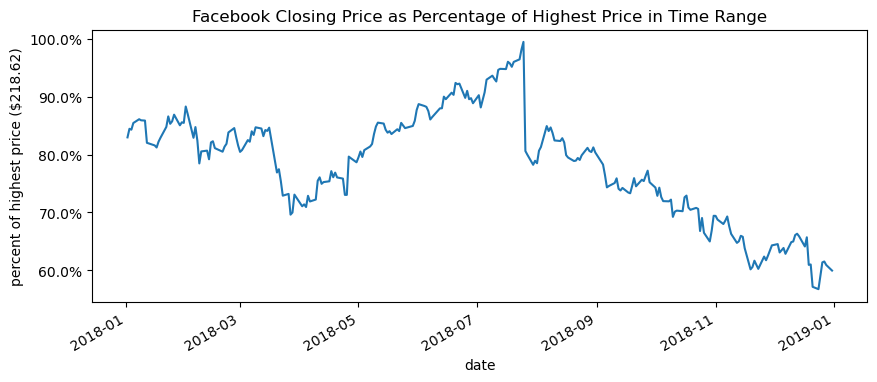

In [261]:
ax=fb.close.plot(
    figsize=(10,4),
    title='Facebook Closing Price as Percentage of Highest Price in Time Range'
)

ax.yaxis.set_major_formatter(
    ticker.PercentFormatter(xmax=fb.high.max())
)

ax.set_yticks([
    fb.high.max()*pct for pct in np.linspace(0.6, 1, num=5)
]) # show round percentages only (60%, 80%, etc.)

ax.set_ylabel(f'percent of highest price (${fb.high.max()})')

plt.show()

MultipleLocator<br>
Say we have the following data. The points only take on integer values for x.

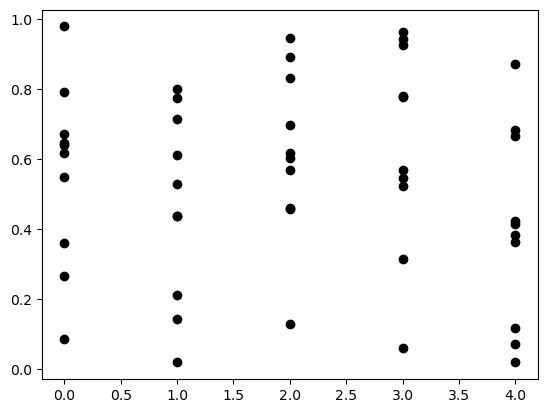

In [262]:
fig, ax = plt.subplots(1,1)
np.random.seed(0)
ax.plot(np.tile(np.arange(0,5), 10), np.random.rand(50), 'ko')

plt.show()

If we don't want to show decimal values on the x-axis, we can use the MultipleLocator . This will give ticks for all multiples of a number specified with the base parameter. To get integer values, we use base=1:

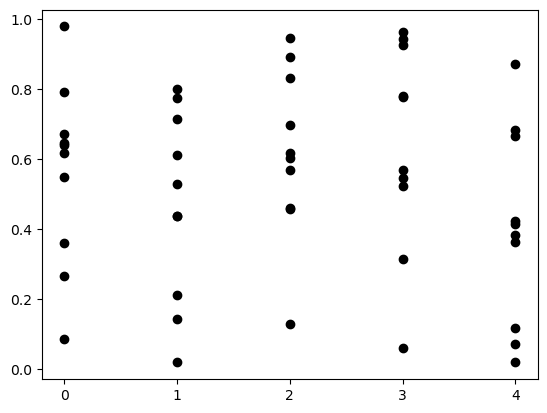

In [263]:
fig, ax = plt.subplots(1,1)
np.random.seed(0)
ax.plot(np.tile(np.arange(0,5), 10), np.random.rand(50), 'ko')
ax.get_xaxis().set_major_locator(
    ticker.MultipleLocator(base=1)
)

plt.show()

### Customizing Visualizations

pandas.plotting subpackage<br>
Pandas provides some extra plotting functions for a few select plot types.

Scatter matrix

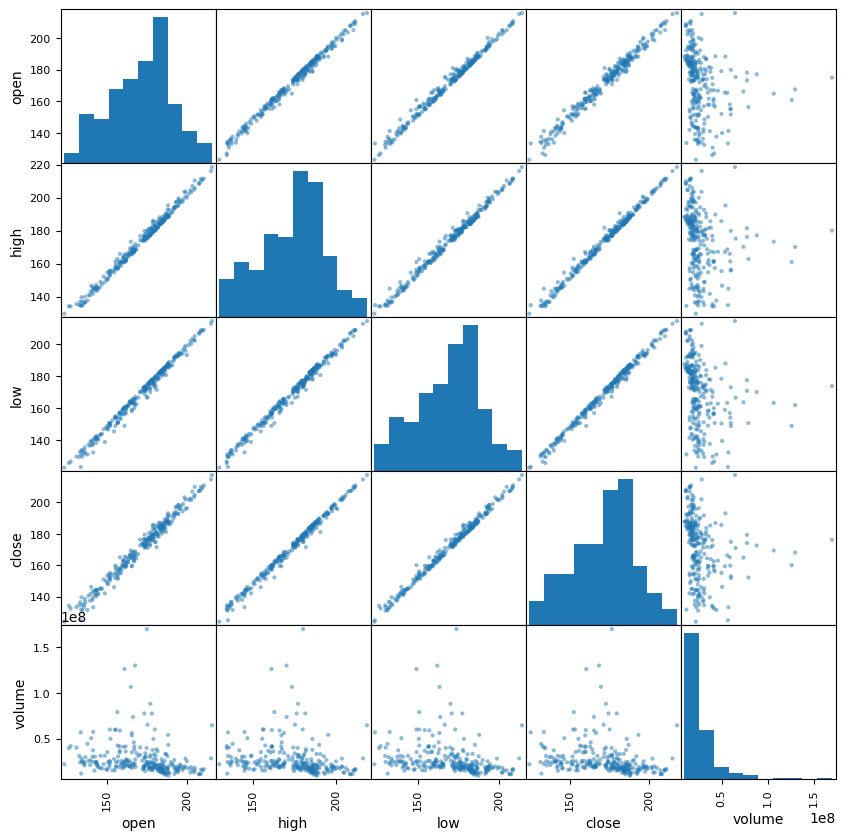

In [264]:
from pandas.plotting import scatter_matrix
scatter_matrix(fb, figsize=(10,10))
plt.show()

Changing the diagonal from histograms to KDE:

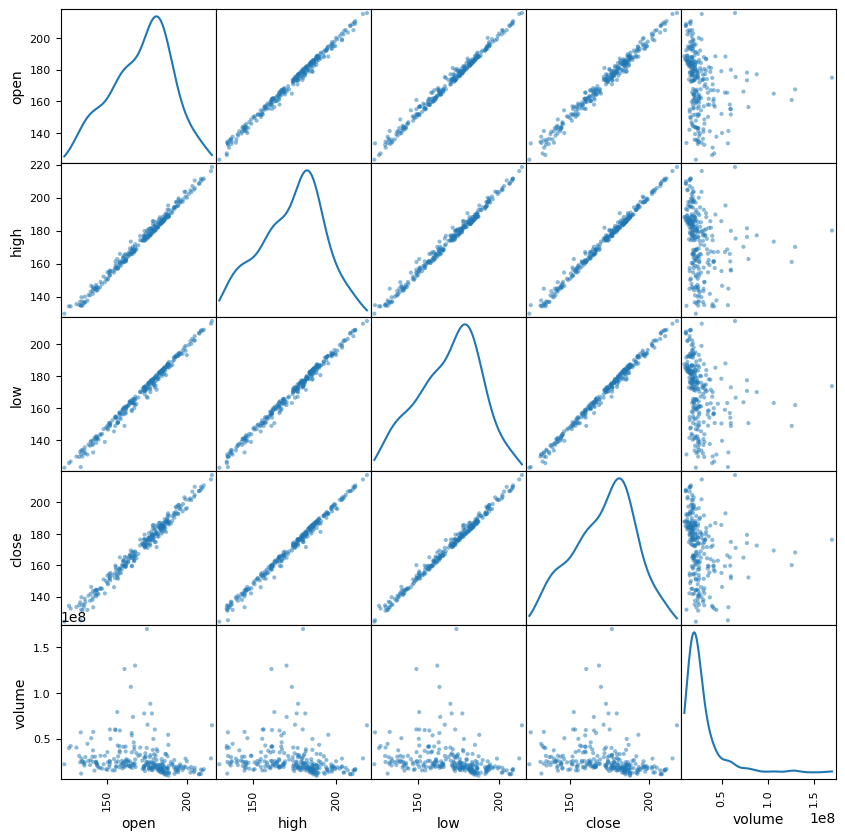

In [265]:
scatter_matrix(fb, diagonal='kde', figsize=(10,10))
plt.show()

Lag plot<br>
Lag plots let us see how the variable correlations with past observations of itself. Random data has no pattern:

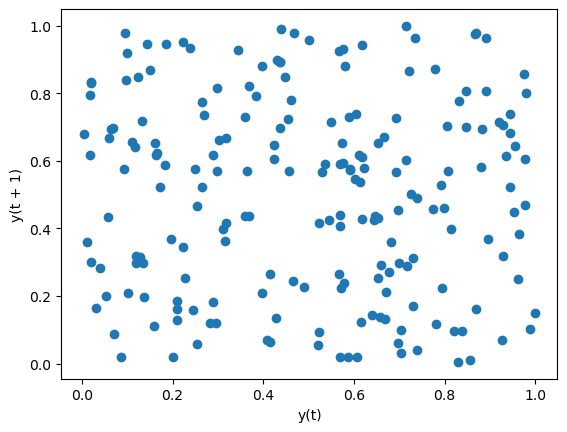

In [266]:
from pandas.plotting import lag_plot
np.random.seed(0) # make this repeatable
lag_plot(pd.Series(np.random.random(size=200)))

plt.show()

Data with some level of correlation to itself (autocorrelation) may have patterns. Stock prices are highly auto-correlated:

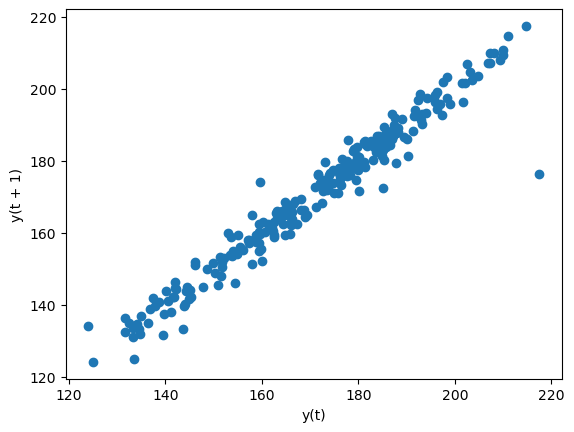

In [267]:
lag_plot(fb.close)

plt.show()

The default lag is 1, but we can alter this with the lag parameter. Let's look at a 5 day lag (a week of trading activity):

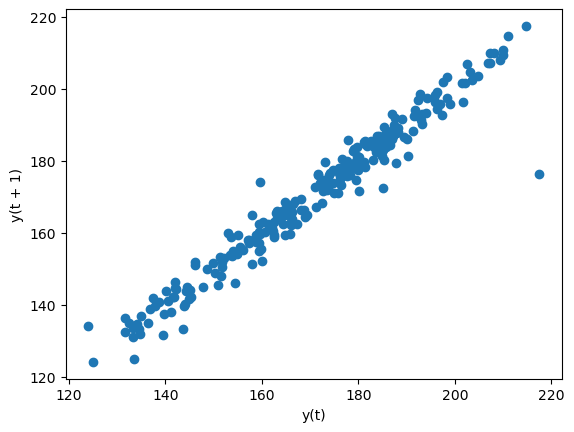

In [268]:
lag_plot(fb.close, lag=1)

plt.show()

Autocorrelation plots<br>
We can use the autocorrelation plot to see if this relationship may be meaningful or just noise. Random data will not have any significant autocorrelation (it stays within the bounds below):

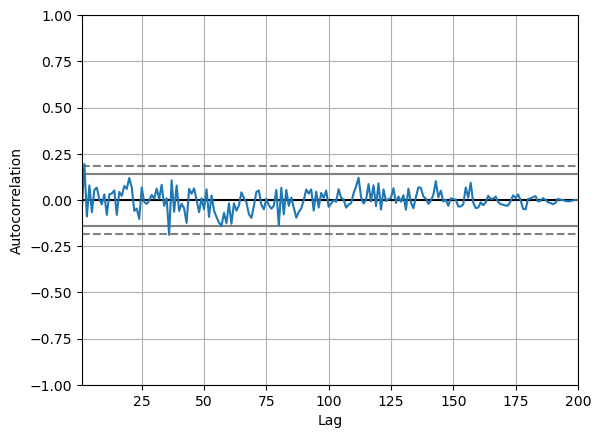

In [269]:
from pandas.plotting import autocorrelation_plot
np.random.seed(0)
autocorrelation_plot(pd.Series(np.random.random(size=200)))

plt.show()

Stock data, on the other hand, does have significant autocorrelation:

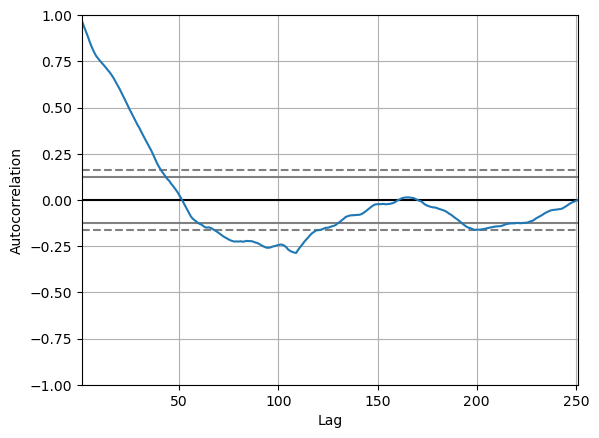

In [270]:
autocorrelation_plot(fb.close)

plt.show()

Boostrap plot<br>
This plot helps us understand the uncertainty in our summary statistics:

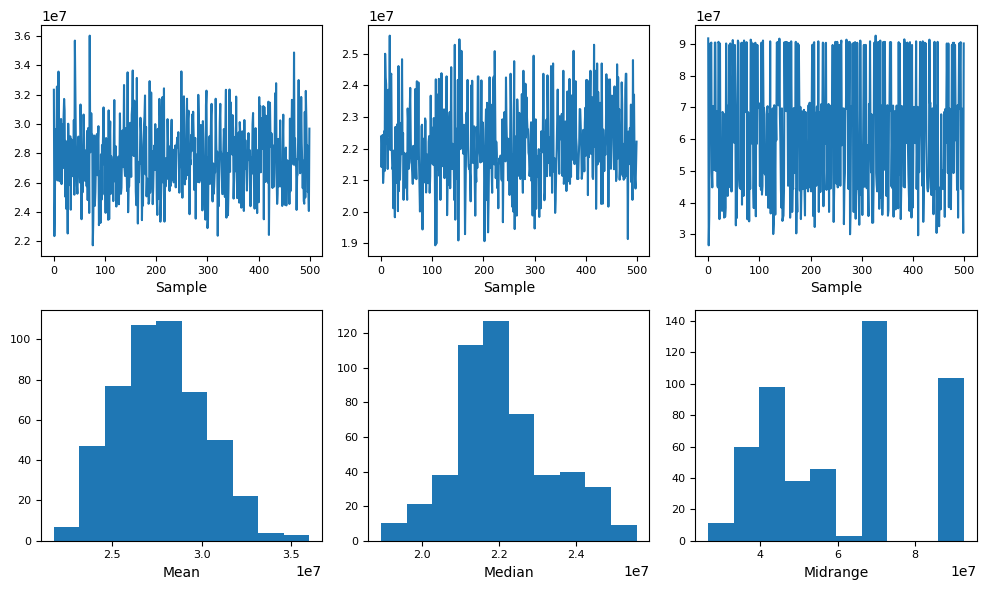

In [271]:
from pandas.plotting import bootstrap_plot
fig = bootstrap_plot(fb.volume, fig=plt.figure(figsize=(10,6)))
plt.show()

## Supplementary Activity

Using the CSV files provided and what we have learned so far in this module complete the following exercises:

1. Using seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami with the magType of mb.

In [272]:
# isolate earthquakes with type mb and their magnitude and tsunami status
mb = quakes.loc[quakes["magType"] == "mb", ["mag", "tsunami"]].dropna()
mb

,mag,tsunami
9,4.7,0
13,4.5,0
55,4.6,0
67,4.6,0
91,4.7,0
...,...,...
9297,4.2,0
9304,5.1,1
9309,4.8,0
9319,4.4,0


In [273]:
# heatmap
mb_corr = mb.corr(numeric_only=True)
mb_corr

,mag,tsunami
mag,1.000000,0.448921
tsunami,0.448921,1.000000


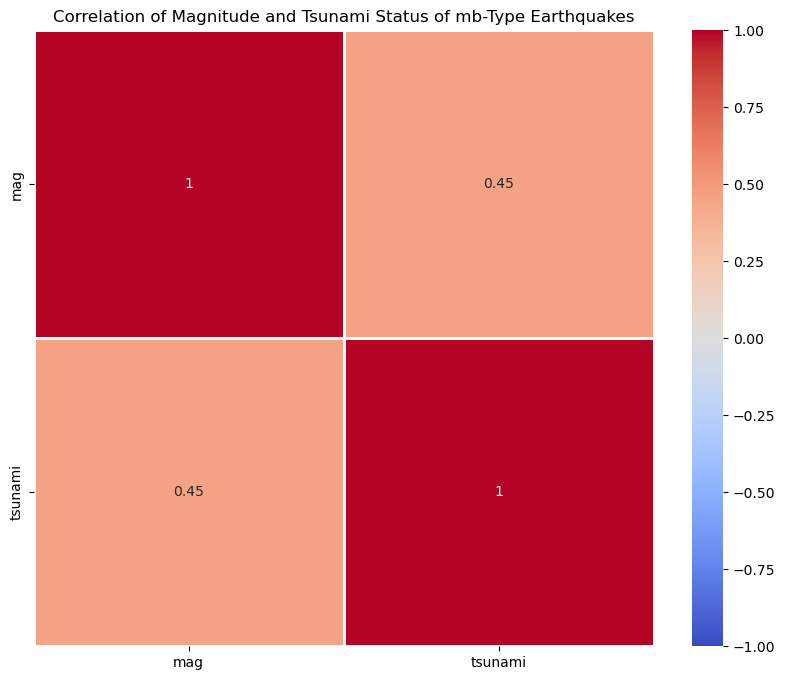

In [274]:
plt.figure(figsize=(10,8))
sns.heatmap(mb_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidth=0.8)
plt.title('Correlation of Magnitude and Tsunami Status of mb-Type Earthquakes')
plt.show()

### Analysis<br>
The visualization shows that the magnitude and tsunami status of mb-type earthquakes have a negative or low positive correlation with each other, having a correlation coefficient of 0.45. This means that as the magnitude of mb-type earthquakes increase, the likelihood of a tsunami occuring may increase, but this relationship is not very strong.

2. Create a box plot of Facebook volume traded and closing prices, and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. The bounds will be at Q1 - 1.5 * IQR and Q3 + 1.5 * IQR. Be sure to use the quantile() method on the data to make this easier. (Pick whichever orientation you prefer for the plot, but make sure to use subplots.)

In [275]:
fb.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2018-01-02 to 2018-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    251 non-null    float64
 1   high    251 non-null    float64
 2   low     251 non-null    float64
 3   close   251 non-null    float64
 4   volume  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [276]:
fb.assign(
volume_bin=pd.cut(fb.volume, 3, labels=['low', 'med', 'high'])
).groupby('volume_bin').boxplot(
    column=['open', 'high', 'low', 'close'],
    layout=(1, 3), figsize=(12, 3)
)
plt.suptitle('Facebook OHLC Boxplots by Volume Traded', y=1.1)

Text(0.5, 1.1, 'Facebook OHLC Boxplots by Volume Traded')

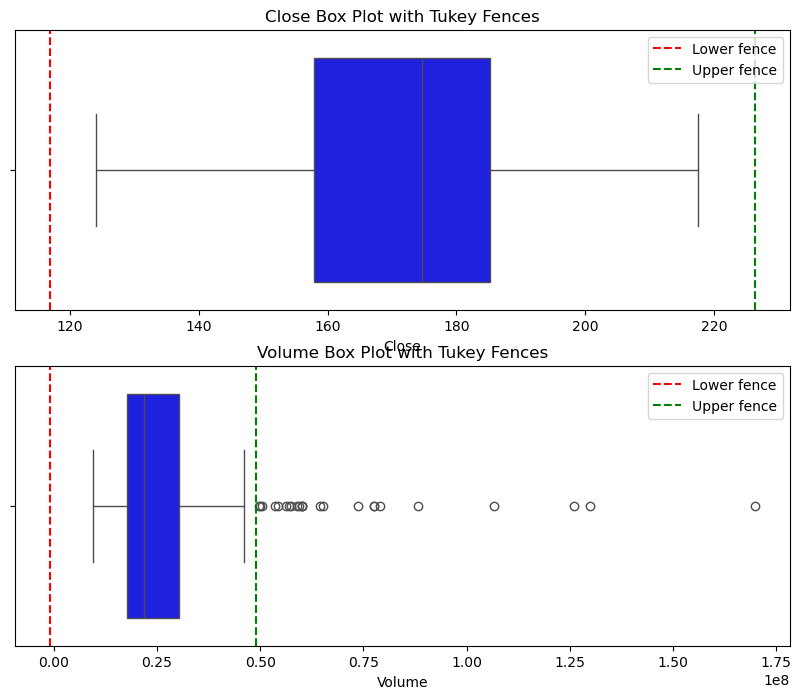

In [285]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, col in zip(axes, ['close', 'volume']):
    series = fb[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    sns.boxplot(x=series, ax=ax, color='blue')
    ax.axvline(lower, color="red", linestyle="--", linewidth=1.5, label="Lower fence")
    ax.axvline(upper, color="green", linestyle="--", linewidth=1.5, label="Upper fence")
    ax.set_title(f"{col.capitalize()} Box Plot with Tukey Fences")
    ax.set_xlabel(col.capitalize())
    ax.legend(loc="upper right")

plt.show()

### Analysis
The box plots show the closing prices and volume of Facebook stock in 2018. The reference lines show the bounds of Tukey fences with a multiplier of 1.5, used for identifying outliers in data. We can see that the closing prices are properly distributed as no outliers are present. On the other hand, the volume has multiple outliers since there are points that fall outside the bounds of the Tukey fences.

3. Fill in the area between the bounds in the plot from exercise #2.

In [288]:
# use Log Transformation (https://hersanyagci.medium.com/detecting-and-handling-outliers-with-pandas-7adbfcd5cad8)
# to normalize skewed data
fb_volume_log = np.log(fb_close_volume['volume'])
fb_volume_log.head()

date
2018-01-02    16.714286
2018-01-03    16.642029
2018-01-04    16.446024
2018-01-05    16.423706
2018-01-08    16.705589
Name: volume, dtype: float64

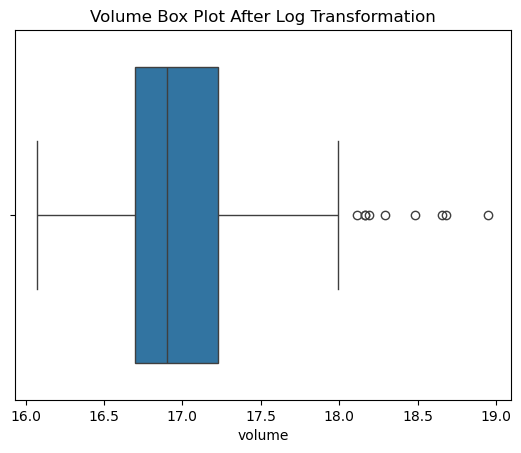

In [293]:
sns.boxplot(x=fb_volume_log)
plt.title('Volume Box Plot After Log Transformation')
plt.show()

### Analysis
The box plot show an enhanced version of the volume box plot. We used the log transformation to make the distribution more normal and easier to visualize. There were still outliers present but the distribution is easier to visualize and understand now.

4. Use axvspan() to shade a rectangle from '2018-07-25' to '2018-07-31', which marks the large decline in Facebook price on a line plot of the closing price.

In [294]:
decline_start = pd.Timestamp('2018-07-25')
decline_end = pd.Timestamp('2018-07-31')

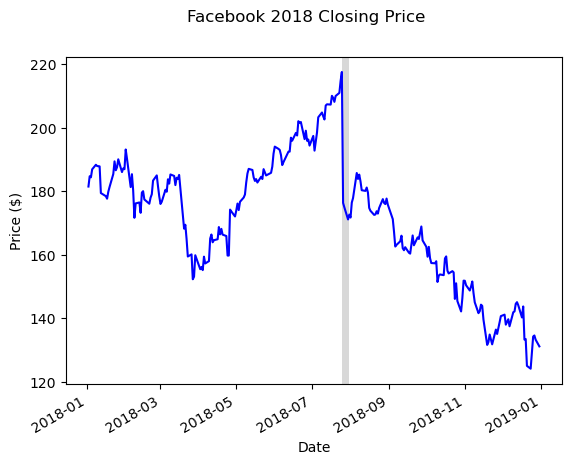

In [295]:
# create line plot
fb.close.plot(kind='line', color='blue')
plt.suptitle('Facebook 2018 Closing Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.axvspan(decline_start, decline_end, facecolor='gray', alpha=0.3)
plt.show()

### Analysis
The line plot shows the closing price of Facebook stock in 2018. The shaded area marks the large decline in Facebook price from July 25 to July 31, 2018. I used the date bounds for shading to make it easier to visualize the decline in Facebook stock price during that period.

6. Modify the reg_resid_plots() function to use a matplotlib colormap instead of cycling between two colors. Remember, for this use case, we should pick a qualitative colormap or make our own.

In [ ]:
# i entered the following code in reg_resid_plot_1.py

"""
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

def reg_resid_plots(data, cmap_name="tab10"):
    num_cols = data.shape[1]
    permutation_count = num_cols * (num_cols - 1)

    fig, ax = plt.subplots(permutation_count, 2, figsize=(15, 4 * permutation_count), squeeze=False)

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i % cmap.N) for i in range(permutation_count)]

    for (x, y), axes, color in zip(
        itertools.permutations(data.columns, 2),
        ax,
        colors
    ):
        sns.regplot(x=x, y=y, data=data, ax=axes[0], color=color)
        sns.residplot(x=x, y=y, data=data, ax=axes[1], color=color)

    fig.tight_layout()
    plt.close(fig)
    return fig
"""

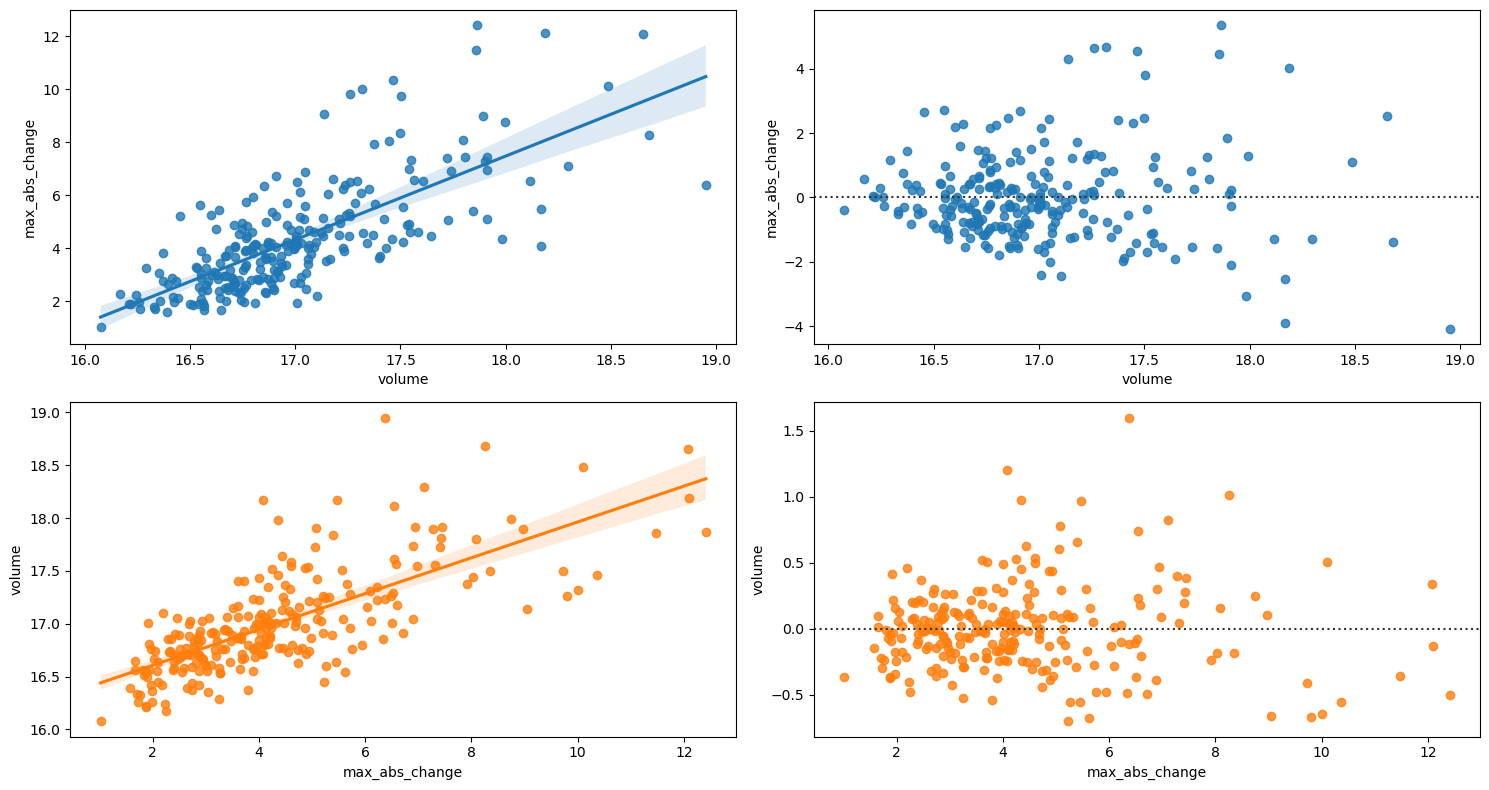

In [301]:
from reg_resid_plot_1 import reg_resid_plots
reg_resid_plots(fb_reg_data)

### Analysis
The visualization shows the regression and residuals for the relationship between the log of the volume and the maximum absolute daily change of Facebook stock prices in 2018. The regression plot shows a strong positive correlation between the two variables. The residual plot shows that there is some variability in the data, but there is no clear pattern in the residuals.

## Conclusion

The hands-on activity allowed us to practice customizing our visualizations using the Seaborn library. We were able to create a variety of different plots and customize them with titles, labels, reference lines, colors, and legends. We also used faceting and plt.subplots to create subplots across different sets in the DataFrame. The supplementary activity provides an opportunity to apply what we have learned in this module and create insightful charts based on the given scenarios. The creation of these visualizations required us to think critically, as well as explore more about Seaborn and MatPlotLib as a whole, which is why I sparingly used reference materials and AI tools to help me create the visualizations. Overall, this activity helped us understand how to use Seaborn to create more informative and visually appealing visualizations.